# Convert Data

In [1]:
!pip install -q transformers==4.46.0 \
    datasets \
    peft \
    trl \
    bitsandbytes \
    accelerate \
    scikit-learn \
    wandb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.5 MB/s eta 0:00:00
Reason for being yanked: This version unfortunately does not work with 3.8 but we did not drop the support yet
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.0/348.0 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 94.4 MB/s eta 0:00:00


In [2]:
import json
import random
import numpy as np
import torch
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model, TaskType
from trl import SFTTrainer, SFTConfig

# Seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

2026-04-23 04:40:18.459641: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776919218.772849      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776919218.858773      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776919219.679573      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776919219.679613      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776919219.679617      22 computation_placer.cc:177] computation placer alr

CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


In [3]:
DATA_PATH = "/kaggle/input/datasets/trungkk/emotion3/all.json"

with open(DATA_PATH, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

print("\nVí dụ mẫu đầu tiên:")
print(json.dumps(raw_data[0], ensure_ascii=False, indent=2))



Ví dụ mẫu đầu tiên:
{
  "turns": [
    {
      "role": "agent",
      "text": "Xin chào! Bạn có thể giúp tôi gì hôm nay?"
    },
    {
      "role": "customer",
      "text": "Chào! Gói hàng của tôi vừa đến sớm hơn dự kiến và tôi thật thích sản phẩm."
    },
    {
      "role": "agent",
      "text": "Rất vui khi nghe điều đó! Bạn có cần hỗ trợ thêm gì về đơn hàng không?"
    },
    {
      "role": "customer",
      "text": "Không, nhưng tôi muốn để lại đánh giá tích cực, bạn có thể chỉ tôi cách làm không?"
    },
    {
      "role": "agent",
      "text": "Bạn chỉ cần truy cập trang đơn hàng, nhấn 'Đánh giá' và chọn số sao cùng bình luận là xong."
    },
    {
      "role": "customer",
      "text": "Vâng, tôi đã để lại đánh giá 5 sao và cảm ơn đội ngũ của bạn!"
    },
    {
      "role": "agent",
      "text": "Cảm ơn bạn!作為謝謝, đây là mã giảm 15% cho đơn mua tiếp theo của bạn: THANKYOU15."
    },
    {
      "role": "customer",
      "text": "Tuyệt vời! Sẽ dùng mã này ngay trong lần

# Visualization

In [4]:
print(raw_data[0].keys())

dict_keys(['turns', 'label'])


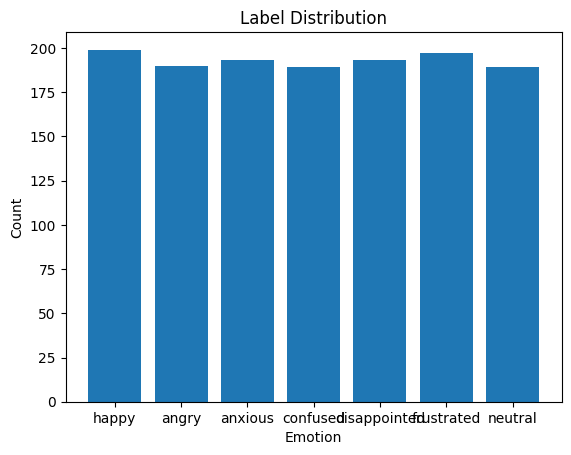

In [5]:
import matplotlib.pyplot as plt
from collections import Counter

labels = [x["label"].lower() for x in raw_data]
counter = Counter(labels)

plt.figure()
plt.bar(counter.keys(), counter.values())
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.title("Label Distribution")
plt.show()

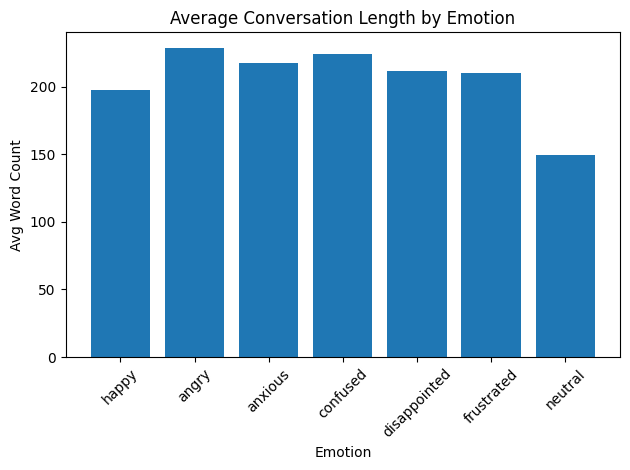

In [6]:
# Độ dài text trung bình theo label
from collections import defaultdict

label_lengths = defaultdict(list)
for x in raw_data:
    total_len = sum(len(t["text"].split()) for t in x["turns"])
    label_lengths[x["label"].lower()].append(total_len)

labels = list(label_lengths.keys())
avg_lengths = [np.mean(label_lengths[l]) for l in labels]

plt.bar(labels, avg_lengths)
plt.xlabel("Emotion")
plt.ylabel("Avg Word Count")
plt.title("Average Conversation Length by Emotion")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

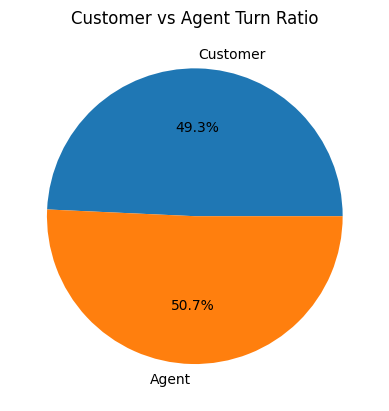

In [7]:
customer_turns = sum(1 for x in raw_data for t in x["turns"] if t["role"] == "customer")
agent_turns = sum(1 for x in raw_data for t in x["turns"] if t["role"] == "agent")

plt.pie([customer_turns, agent_turns],
        labels=["Customer", "Agent"],
        autopct="%1.1f%%")
plt.title("Customer vs Agent Turn Ratio")
plt.show()

# Tiền xử lí

In [8]:
LABELS = ["neutral","happy","confused","anxious","frustrated","disappointed","angry"]

LABELS_STR = ", ".join(LABELS)

In [9]:
def format_prompt(example):
    context = "\n".join(
        f"{'Khách' if t['role']=='customer' else 'Agent'}: {t['text']}"
        for t in example["turns"]
    )

    prompt = f"""
Bạn là chuyên gia phân tích cảm xúc khách hàng.

Chỉ trả lời DUY NHẤT một từ trong danh sách sau:
neutral, happy, confused, anxious, frustrated, disappointed, angry

KHÔNG giải thích.

Hội thoại:
{context}

Cảm xúc:
""".strip()

    completion = example["label"].lower().strip()

    return {
        "prompt": prompt,
        "completion": completion
    }

# Fine-tune

In [10]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig
from datasets import load_dataset
import warnings
warnings.filterwarnings("ignore")
import torch
print(torch.cuda.get_device_name(0))
print("bfloat16 support:", torch.cuda.is_bf16_supported())

model_id = "Qwen/Qwen2.5-3B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.model_max_length = 1024

# Load 4-bit
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16   # ← đổi từ bfloat16
)

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
    attn_implementation="eager"
    # ← bỏ torch_dtype hoàn toàn
)



model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=8,           
    lora_alpha=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)

raw_dataset = load_dataset(
    "json",
    data_files="/kaggle/input/datasets/trungkk/emotion/all.json"
)["train"]

dataset = raw_dataset.map(format_prompt)
dataset = dataset.remove_columns(["turns", "label"])
# Training
training_args = SFTConfig(
    output_dir="./Qwen2.5-3B-Instruct",
    num_train_epochs=50,              # tăng epoch để học đủ
    per_device_train_batch_size=8,    # tăng batch
    gradient_accumulation_steps=1,   
    learning_rate=2e-4,
    warmup_steps=5,
    lr_scheduler_type="cosine",
    bf16=False,
    fp16=True,
    packing=False,                    
    max_seq_length=512,              
    logging_steps=1,
    save_strategy="epoch",
    dataset_text_field="text",
    report_to="none"
)

trainer = SFTTrainer(
    model=model,
    train_dataset=dataset,
    args=training_args,
    processing_class=tokenizer,
)

trainer.train()
trainer.save_model("./Qwen2.5-3B-Instruct")

Tesla T4
bfloat16 support: True


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Adding EOS to train dataset:   0%|          | 0/88 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/88 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/88 [00:00<?, ? examples/s]

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Step,Training Loss
1,11.025600
2,12.637700
3,12.200300
4,10.950800
5,10.636100
6,9.381900
7,7.211500
8,8.828300
9,8.479300
10,7.970400


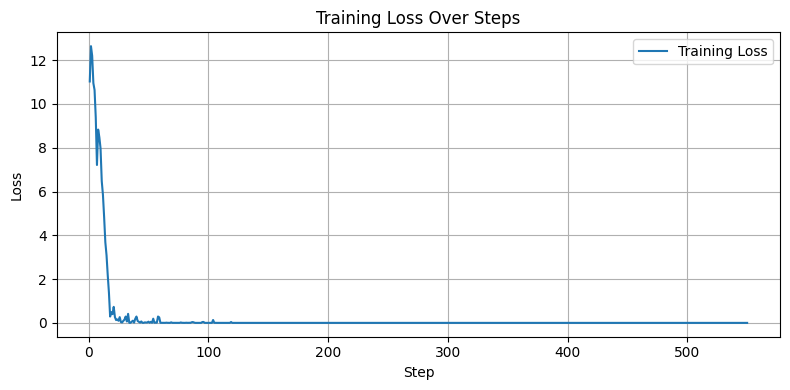

In [11]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

steps = []

losses = []

for log in log_history:
    if "loss" in log:
        steps.append(log["step"])
        losses.append(log["loss"])

plt.figure(figsize=(8, 4))
plt.plot(steps, losses, marker="", label="Training Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss Over Steps")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Inference 

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

# =======================
# CONFIG
# =======================
model_id = "Qwen/Qwen2.5-3B-Instruct"
lora_path = "./Qwen2.5-3B-Instruct"

LABELS = [
    "neutral",
    "happy",
    "confused",
    "anxious",
    "frustrated",
    "disappointed",
    "angry"
]

# =======================
# LOAD MODEL
# =======================
tokenizer = AutoTokenizer.from_pretrained(model_id)

base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

model = PeftModel.from_pretrained(base_model, lora_path)
model.eval()

# =======================
# PAD TOKEN FIX (IMPORTANT)
# =======================
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "left"
model.config.pad_token_id = tokenizer.pad_token_id

print("pad_token     :", tokenizer.pad_token)
print("pad_token_id  :", tokenizer.pad_token_id)

# =======================
# BUILD PROMPT
# =======================
def build_prompt(conversation_turns):
    conv = "\n".join(
        f"{'Khách' if t['role']=='customer' else 'Agent'}: {t['text']}"
        for t in conversation_turns
    )

    return f"""
Bạn là chuyên gia phân tích cảm xúc khách hàng.

Chỉ được trả lời DUY NHẤT một từ trong danh sách sau:
{LABELS_STR}

KHÔNG giải thích.

Hội thoại:
{conv}

Cảm xúc:
""".strip()

# =======================
# EXTRACT LABEL (ROBUST)
# =======================
def extract_label(text):
    text = text.lower().strip()

    for label in LABELS:
        if label in text:
            return label

    return "unknown"

# =======================
# PREDICT
# =======================
def predict_emotion_full(conversation_turns):
    prompt = build_prompt(conversation_turns)

    messages = [{"role": "user", "content": prompt}]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=20,     # FIX
            temperature=0.0,       # FIX
            do_sample=False,       # FIX
            pad_token_id=tokenizer.pad_token_id
        )

    generated = outputs[0][inputs["input_ids"].shape[1]:]
    result = tokenizer.decode(generated, skip_special_tokens=True).strip()

    return result

# =======================
# EVALUATE
# =======================
def evaluate_full(data, verbose=False):
    correct = 0

    for i, sample in enumerate(data):
        pred_text = predict_emotion_full(sample["turns"])
        pred_label = extract_label(pred_text)
        true_label = sample["label"].lower()

        if pred_label == true_label:
            correct += 1

        if verbose:
            print(f"\n--- Sample {i} ---")
            print("PRED TEXT :", pred_text)
            print("PRED LABEL:", pred_label)
            print("TRUE LABEL:", true_label)

    acc = correct / len(data)
    print(f"\n✅ Accuracy: {acc:.4f} ({correct}/{len(data)})")

    return acc

# =======================
# RUN
# =======================
raw_data_test = raw_data * 5  # test scale

evaluate_full(raw_data, verbose=True)

In [13]:
import re

def extract_label(text):
    text = text.lower()

    for lbl in LABELS:
        if re.search(rf"\b{lbl}\b", text):
            return lbl

    return "unknown"

In [14]:
# print(raw_data_test)
print(len(raw_data))

1350


In [ ]:
from sklearn.metrics import recall_score, classification_report
import numpy as np

def evaluate_recall(data, label=""):
    y_true, y_pred = [], []
    
    for sample in data:
        pred_text = predict_emotion_full(sample["turns"])
        pred_label = extract_label(pred_text)
        true_label = sample["label"].lower()

        y_true.append(true_label)
        y_pred.append(pred_label)
    
    print(f"\n===== {label} =====")

    print(classification_report(
        y_true,
        y_pred,
        labels=LABELS,
        zero_division=0
    ))

    acc = np.mean(np.array(y_true) == np.array(y_pred))

    print(f"Accuracy         : {acc:.2f}")

    return y_true, y_pred

y_true,y_pred=evaluate_recall(dataset, label="Test")


===== Test =====
              precision    recall  f1-score   support

     neutral       1.00      0.75      0.86       388
       happy       0.91      0.80      0.85       133
    confused       0.70      0.86      0.77       106
     anxious       0.88      0.91      0.90       136
  frustrated       0.81      0.85      0.83       261
disappointed       0.80      0.87      0.83       189
       angry       0.95      0.76      0.84       116

    accuracy                           0.82      1329

Accuracy         : 0.82
